# ZeRO-1, ZeRO-2, ZeRO-3 on 32 virtual GPUs

**ERA V5 — Session 12 assignment.**

I build 32 virtual GPUs out of CPU threads, train one small model on them with
plain data parallelism (DDP), then with ZeRO stages 1, 2 and 3, and measure
what changes: **memory per GPU**, **bytes moved over the interconnect**, and
**work per GPU**.  Every stage is checked to produce the *same* weights,
bit for bit — ZeRO is a memory trick, not a different optimizer.

The simulator is `zero_sim.py` (written next to this notebook by the first
cell if it is missing, so this runs on Colab with no setup).

**What is real and what is pretend**

| | |
|---|---|
| a *virtual GPU* | a Python object with a private memory ledger and its own thread. "Memory" = bytes of tensors currently held on it — measured, not estimated |
| the *fabric* | one object that performs all-reduce / reduce-scatter / all-gather and charges each GPU what a ring implementation would move |
| the model | a 4-layer MLP, forward **and backward written by hand**, so the ZeRO-3 gather / free / re-gather dance is visible line by line |
| mixed precision | real: bf16 params and grads, fp32 master weights and Adam moments — that is the famous 16 bytes/parameter |
| bf16 matmul | this CPU has no fast bf16 kernel, so the multiply runs in fp32 and rounds to bf16 — which is exactly what a tensor core does |
| wall-clock time | **not** a proxy for GPU time — 32 Python threads share one GIL. I report analytic counts and an isolated micro-benchmark instead |

In [1]:
# Self-contained: write the simulator next to the notebook if it is not there (e.g. on Colab).
import os, textwrap
if not os.path.exists("zero_sim.py"):
    open("zero_sim.py", "w").write('"""\nzero_sim.py — 32 virtual GPUs, one demo model, ZeRO stages 0/1/2/3.\n\nERA V5, Session 12.\n\nWhat is real here and what is pretend\n-------------------------------------\n* A "virtual GPU" is a Python object with a private memory ledger and its own\n  worker thread.  Every tensor it holds is registered with the ledger, so\n  "memory" means "bytes of tensors currently living on this GPU" — measured,\n  not estimated.  Compute really does run on 32 threads at once.\n* The "fabric" (interconnect) is one object that performs the collectives —\n  all-reduce, reduce-scatter, all-gather — and charges each GPU the bytes a\n  ring implementation would move.  The arithmetic is done once in-process;\n  the accounting is what we care about.\n* The model\'s forward AND backward are written by hand (no autograd), so the\n  ZeRO-3 dance — gather a layer\'s weights, use them, throw them away, gather\n  them again in backward — is visible line by line.\n* Mixed precision is real: bf16 working copies of params and grads, fp32\n  master weights and Adam moments.  That is where the famous\n  "16 bytes per parameter" comes from:  2 + 2 + 4 + 4 + 4.\n* This CPU has no fast bf16 matmul, so the multiply runs in fp32 and the\n  result is rounded to bf16 — which is exactly what a bf16 tensor core does\n  (bf16 in, fp32 accumulate, bf16 out).  Stored tensors stay bf16.\n\nEverything is seeded.  All four strategies produce bit-identical weights.\n"""\nfrom __future__ import annotations\n\nimport math\nimport threading\nimport time\nfrom collections import defaultdict\nfrom concurrent.futures import ThreadPoolExecutor\nfrom dataclasses import dataclass, field\n\nimport torch\n\ntorch.set_num_threads(1)  # one intra-op thread per virtual GPU, no oversubscription\n\nBF16 = torch.bfloat16\nFP32 = torch.float32\n\n# Memory categories.  The first five are the "model states" of the ZeRO paper.\nCAT_P, CAT_G, CAT_M, CAT_A1, CAT_A2 = "params bf16", "grads bf16", "master fp32", "adam m fp32", "adam v fp32"\nCAT_ACT, CAT_TMP = "activations", "gathered layer (temp)"\nMODEL_STATES = (CAT_P, CAT_G, CAT_M, CAT_A1, CAT_A2)\n\n\n# ---------------------------------------------------------------------------\n# 1. Virtual hardware\n# ---------------------------------------------------------------------------\nclass VirtualGPU:\n    """A GPU, for our purposes: a private memory pool with a rank number.\n\n    hold(name, category, tensor) puts a tensor \'on\' the GPU;  drop(name) frees\n    it.  The ledger tracks current bytes per category, the peak total (with a\n    snapshot of the breakdown at that moment) and the peak of model states.\n    """\n\n    def __init__(self, rank: int):\n        self.rank = rank\n        self._held: dict[str, tuple[str, torch.Tensor]] = {}\n        self.cur: dict[str, int] = defaultdict(int)\n        self.peak = 0\n        self.peak_breakdown: dict[str, int] = {}\n        self.peak_model_states = 0\n        self.busy = defaultdict(float)  # seconds this GPU spent computing, per phase\n\n    def hold(self, name: str, category: str, t: torch.Tensor) -> torch.Tensor:\n        assert name not in self._held, f"gpu{self.rank}: {name!r} already held"\n        self._held[name] = (category, t)\n        self.cur[category] += t.numel() * t.element_size()\n        total = self.total()\n        if total > self.peak:\n            self.peak = total\n            self.peak_breakdown = self.snapshot()\n        self.peak_model_states = max(self.peak_model_states, self.model_states())\n        return t\n\n    def drop(self, name: str) -> torch.Tensor:\n        cat, t = self._held.pop(name)\n        self.cur[cat] -= t.numel() * t.element_size()\n        return t\n\n    def get(self, name: str) -> torch.Tensor:\n        return self._held[name][1]\n\n    def total(self) -> int:\n        return sum(self.cur.values())\n\n    def model_states(self) -> int:\n        return sum(self.cur[c] for c in MODEL_STATES)\n\n    def snapshot(self) -> dict[str, int]:\n        return {k: v for k, v in self.cur.items() if v}\n\n\nclass Fabric:\n    """The interconnect between the GPUs.\n\n    Every collective is a synchronisation point: nobody continues until all\n    N inputs are in.  Bytes charged per GPU follow the ring algorithm:\n\n        all_reduce      2 (N-1)/N  x  size        (= reduce-scatter + all-gather)\n        reduce_scatter    (N-1)/N  x  size\n        all_gather        (N-1)/N  x  size\n\n    Sums are done in fp32 in a fixed order so every stage sees exactly the\n    same reduced gradient.\n    """\n\n    def __init__(self, n: int):\n        self.n = n\n        self.bytes_per_gpu = 0.0\n        self.calls: dict[str, int] = defaultdict(int)\n        self.seconds = 0.0\n        self._lock = threading.Lock()\n\n    def _charge(self, kind: str, full_nbytes: int, factor: float, t0: float):\n        with self._lock:\n            self.bytes_per_gpu += factor * (self.n - 1) / self.n * full_nbytes\n            self.calls[kind] += 1\n            self.seconds += time.perf_counter() - t0\n\n    def _mean(self, tensors: list[torch.Tensor]) -> torch.Tensor:\n        return torch.stack([t.float() for t in tensors]).sum(0).div_(self.n)\n\n    def all_reduce(self, tensors: list[torch.Tensor]) -> list[torch.Tensor]:\n        """Everyone contributes a full tensor, everyone gets back the mean."""\n        t0 = time.perf_counter()\n        assert len(tensors) == self.n\n        mean = self._mean(tensors).to(tensors[0].dtype)\n        out = [mean.clone() for _ in range(self.n)]\n        self._charge("all_reduce", tensors[0].numel() * tensors[0].element_size(), 2.0, t0)\n        return out\n\n    def reduce_scatter(self, tensors: list[torch.Tensor]) -> list[torch.Tensor]:\n        """Everyone contributes a full tensor; GPU i gets back only chunk i of the mean."""\n        t0 = time.perf_counter()\n        assert len(tensors) == self.n\n        chunks = self._mean(tensors).to(tensors[0].dtype).chunk(self.n)\n        out = [c.clone() for c in chunks]\n        self._charge("reduce_scatter", tensors[0].numel() * tensors[0].element_size(), 1.0, t0)\n        return out\n\n    def all_gather(self, shards: list[torch.Tensor]) -> list[torch.Tensor]:\n        """GPU i contributes chunk i; everyone gets back the full tensor."""\n        t0 = time.perf_counter()\n        assert len(shards) == self.n\n        full = torch.cat(shards)\n        out = [full.clone() for _ in range(self.n)]\n        self._charge("all_gather", full.numel() * full.element_size(), 1.0, t0)\n        return out\n\n\n# ---------------------------------------------------------------------------\n# 2. The demo model: a 4-layer MLP with hand-written forward and backward\n# ---------------------------------------------------------------------------\n@dataclass\nclass ParamSpec:\n    name: str\n    shape: tuple[int, ...]\n    numel: int\n    padded: int          # numel rounded up to a multiple of n_gpus so it shards evenly\n    n_gpus: int\n\n    @property\n    def shard(self) -> int:\n        return self.padded // self.n_gpus\n\n\n@dataclass\nclass ModelSpec:\n    dims: tuple[int, ...]\n    n_gpus: int\n    params: list[ParamSpec] = field(default_factory=list)\n\n    @staticmethod\n    def build(dims: tuple[int, ...], n_gpus: int) -> "ModelSpec":\n        spec = ModelSpec(dims, n_gpus)\n        for i in range(len(dims) - 1):\n            for nm, shape in ((f"L{i}.W", (dims[i + 1], dims[i])), (f"L{i}.b", (dims[i + 1],))):\n                numel = math.prod(shape)\n                padded = math.ceil(numel / n_gpus) * n_gpus\n                spec.params.append(ParamSpec(nm, shape, numel, padded, n_gpus))\n        return spec\n\n    @property\n    def n_layers(self) -> int:\n        return len(self.dims) - 1\n\n    def layer_params(self, i: int) -> tuple[ParamSpec, ParamSpec]:\n        return self.params[2 * i], self.params[2 * i + 1]\n\n    @property\n    def total_params(self) -> int:\n        return sum(p.numel for p in self.params)\n\n    @property\n    def largest_layer_params(self) -> int:\n        return max(self.params[2 * i].numel + self.params[2 * i + 1].numel for i in range(self.n_layers))\n\n    def init_master(self, seed: int) -> dict[str, torch.Tensor]:\n        """fp32 master weights, flat + padded, uniform(-1/sqrt(fan_in), +1/sqrt(fan_in)) like nn.Linear."""\n        g = torch.Generator().manual_seed(seed)\n        out = {}\n        for i in range(self.n_layers):\n            W, b = self.layer_params(i)\n            bound = 1.0 / math.sqrt(self.dims[i])\n            w = (torch.rand(W.numel, generator=g) * 2 - 1) * bound\n            bb = (torch.rand(b.numel, generator=g) * 2 - 1) * bound\n            out[W.name] = torch.cat([w, torch.zeros(W.padded - W.numel)])\n            out[b.name] = torch.cat([bb, torch.zeros(b.padded - b.numel)])\n        return out\n\n\ndef mm_bf16(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:\n    """Emulates a bf16 tensor-core matmul: bf16 in, fp32 accumulate, bf16 out."""\n    return (a.float() @ b.float()).to(BF16)\n\n\ndef view_param(flat: torch.Tensor, p: ParamSpec) -> torch.Tensor:\n    return flat[: p.numel].view(p.shape)\n\n\ndef layer_forward(gpu: VirtualGPU, i: int, spec: ModelSpec, x: torch.Tensor,\n                  W: torch.Tensor, b: torch.Tensor, last: bool) -> torch.Tensor:\n    """y = relu(x W^T + b)  (no relu on the last layer).  Saves what backward needs."""\n    Wp, _ = spec.layer_params(i)\n    gpu.hold(f"act/L{i}.in", CAT_ACT, x)                    # needed for dW\n    h = mm_bf16(x, view_param(W, Wp).T) + b[: spec.dims[i + 1]]\n    if last:\n        return h\n    mask = h > 0\n    gpu.hold(f"act/L{i}.mask", CAT_ACT, mask)                # needed for relu backward\n    return h * mask\n\n\ndef layer_backward(gpu: VirtualGPU, i: int, spec: ModelSpec, dout: torch.Tensor,\n                   W: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None]:\n    """Given dL/dy for layer i, return (dW_flat, db_flat, dL/dx).  Frees saved activations."""\n    Wp, bp = spec.layer_params(i)\n    x = gpu.drop(f"act/L{i}.in")\n    dW = mm_bf16(dout.T, x).reshape(-1)                      # (out,in) -> flat\n    db = dout.float().sum(0).to(BF16)\n    dW_flat = torch.cat([dW, dW.new_zeros(Wp.padded - Wp.numel)])\n    db_flat = torch.cat([db, db.new_zeros(bp.padded - bp.numel)])\n    if i == 0:\n        dx = None\n    else:\n        dx = mm_bf16(dout, view_param(W, Wp))                 # (B,out) @ (out,in)\n        mask = gpu.drop(f"act/L{i-1}.mask")\n        dx = dx * mask\n    return dW_flat, db_flat, dx\n\n\ndef loss_and_grad(logits_bf16: torch.Tensor, y: torch.Tensor) -> tuple[float, torch.Tensor]:\n    """Cross-entropy in fp32; returns (loss, dL/dlogits in bf16)."""\n    logits = logits_bf16.float()\n    logp = torch.log_softmax(logits, dim=1)\n    loss = -logp.gather(1, y[:, None]).mean()\n    d = torch.softmax(logits, dim=1)\n    d[torch.arange(len(y)), y] -= 1.0\n    d /= len(y)\n    return loss.item(), d.to(BF16)\n\n\ndef adam_update(master: torch.Tensor, grad: torch.Tensor, m: torch.Tensor, v: torch.Tensor,\n                step: int, lr: float, b1=0.9, b2=0.999, eps=1e-8) -> None:\n    """Plain Adam, in place, on fp32 tensors.  Same maths whether given a full tensor or a shard."""\n    g = grad.float()\n    m.mul_(b1).add_(g, alpha=1 - b1)\n    v.mul_(b2).addcmul_(g, g, value=1 - b2)\n    m_hat = m / (1 - b1 ** step)\n    v_hat = v / (1 - b2 ** step)\n    master.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)\n\n\n# ---------------------------------------------------------------------------\n# 3. Synthetic data: a fixed random "teacher" labels random inputs\n# ---------------------------------------------------------------------------\nclass TeacherData:\n    def __init__(self, dims: tuple[int, ...], seed: int):\n        g = torch.Generator().manual_seed(seed)\n        self.in_dim, self.n_cls = dims[0], dims[-1]\n        self.W1 = torch.randn(dims[0], 128, generator=g) / math.sqrt(dims[0])\n        self.W2 = torch.randn(128, dims[-1], generator=g) / math.sqrt(128)\n        self.seed = seed\n\n    def batch(self, step: int, n: int) -> tuple[torch.Tensor, torch.Tensor]:\n        g = torch.Generator().manual_seed(self.seed * 100_003 + step)\n        x = torch.randn(n, self.in_dim, generator=g)\n        y = (torch.tanh(x @ self.W1) @ self.W2).argmax(1)\n        return x, y\n\n\n# ---------------------------------------------------------------------------\n# 4. The four strategies\n# ---------------------------------------------------------------------------\nclass ZeroSimulator:\n    """Trains one model with data parallelism across N virtual GPUs at ZeRO stage 0, 1, 2 or 3.\n\n    stage 0 : classic DDP.  Every GPU: full params, full grads, full optimizer state.\n              all-reduce grads at the end of backward.\n    stage 1 : optimizer state sharded (each GPU owns 1/N of master, m, v).\n              reduce-scatter grads AFTER backward -> update my shard -> all-gather bf16 params.\n    stage 2 : + gradients sharded: reduce-scatter each layer\'s grad DURING backward, the moment it\n              exists, so the full gradient never sits in memory.\n    stage 3 : + parameters sharded: all-gather a layer just before it is used — in forward AND\n              again in backward — and free it right after.\n    """\n\n    def __init__(self, stage: int, spec: ModelSpec, seed: int = 0, lr: float = 1e-3,\n                 per_gpu_batch: int = 64):\n        assert stage in (0, 1, 2, 3)\n        self.stage, self.spec, self.n, self.lr = stage, spec, spec.n_gpus, lr\n        self.B = per_gpu_batch\n        self.gpus = [VirtualGPU(r) for r in range(self.n)]\n        self.fabric = Fabric(self.n)\n        self.pool = ThreadPoolExecutor(max_workers=self.n)\n        self.data = TeacherData(spec.dims, seed + 1)\n        self.wall = defaultdict(float)          # wall-clock per phase (the whole cluster)\n        self.timeline: list[tuple[str, dict[str, int]]] = []   # GPU-0 memory after each phase, last step\n        self.optimizer_elements_per_gpu = 0\n        self._load(spec.init_master(seed))\n\n    # -- helpers -------------------------------------------------------------\n    def par(self, phase: str, fn, *iters):\n        """Run fn(gpu, ...) on every GPU concurrently, one thread each, timing each GPU\'s own work."""\n        def timed(gpu, *args):\n            t0 = time.perf_counter()\n            out = fn(gpu, *args)\n            gpu.busy[phase] += time.perf_counter() - t0\n            return out\n        return list(self.pool.map(timed, self.gpus, *iters))\n\n    def _mark(self, label: str):\n        self.timeline.append((label, self.gpus[0].snapshot()))\n\n    def _load(self, master: dict[str, torch.Tensor]):\n        """Initial placement.  Like loading a checkpoint: not charged to the fabric."""\n        sharded_opt = self.stage >= 1\n        sharded_params = self.stage == 3\n        for p in self.spec.params:\n            full = master[p.name]\n            for gpu in self.gpus:\n                r = gpu.rank\n                sl = slice(r * p.shard, (r + 1) * p.shard)\n                if sharded_opt:\n                    gpu.hold(f"{p.name}/master", CAT_M, full[sl].clone())\n                    gpu.hold(f"{p.name}/m", CAT_A1, torch.zeros(p.shard))\n                    gpu.hold(f"{p.name}/v", CAT_A2, torch.zeros(p.shard))\n                else:\n                    gpu.hold(f"{p.name}/master", CAT_M, full.clone())\n                    gpu.hold(f"{p.name}/m", CAT_A1, torch.zeros(p.padded))\n                    gpu.hold(f"{p.name}/v", CAT_A2, torch.zeros(p.padded))\n                if sharded_params:\n                    gpu.hold(f"{p.name}/bf16", CAT_P, full[sl].to(BF16))\n                else:\n                    gpu.hold(f"{p.name}/bf16", CAT_P, full.to(BF16))\n\n    # -- one training step ---------------------------------------------------\n    def step(self, step_no: int) -> float:\n        spec, n = self.spec, self.n\n        self.timeline = []\n        self._mark("start")\n        x_all, y_all = self.data.batch(step_no, self.B * n)\n        xs = [x_all[r * self.B:(r + 1) * self.B].to(BF16) for r in range(n)]\n        ys = [y_all[r * self.B:(r + 1) * self.B] for r in range(n)]\n\n        # ---- forward, layer by layer (lockstep, so ZeRO-3 can gather between layers)\n        t0 = time.perf_counter()\n        acts = xs\n        for i in range(spec.n_layers):\n            Wp, bp = spec.layer_params(i)\n            if self.stage == 3:\n                self._gather_layer(i)\n                self._mark(f"fwd L{i} gathered")\n            last = i == spec.n_layers - 1\n            acts = self.par("forward", lambda g, a, i=i, last=last: layer_forward(\n                g, i, spec, a, g.get(self._wname(Wp)), g.get(self._wname(bp)), last), acts)\n            if self.stage == 3:\n                self._free_layer(i)\n            self._mark(f"fwd L{i}")\n        losses_and_d = [loss_and_grad(a, y) for a, y in zip(acts, ys)]\n        loss = sum(l for l, _ in losses_and_d) / n\n        douts = [d for _, d in losses_and_d]\n        self.wall["forward"] += time.perf_counter() - t0\n\n        # ---- backward, layer by layer, last layer first\n        t0 = time.perf_counter()\n        for i in reversed(range(spec.n_layers)):\n            Wp, bp = spec.layer_params(i)\n            if self.stage == 3:\n                self._gather_layer(i)                                  # 2nd gather of this layer\n                self._mark(f"bwd L{i} gathered")\n            res = self.par("backward", lambda g, d, i=i: layer_backward(g, i, spec, d, g.get(self._wname(Wp))), douts)\n            if self.stage == 3:\n                self._free_layer(i)\n            douts = [r[2] for r in res]\n            for p, k in ((Wp, 0), (bp, 1)):\n                grads = [r[k] for r in res]\n                if self.stage >= 2:\n                    # ZeRO-2/3: reduce-scatter this layer\'s grad right away; keep only my shard\n                    self._collect(lambda: [g.hold(f"{p.name}/grad", CAT_G, s)\n                                           for g, s in zip(self.gpus, self.fabric.reduce_scatter(grads))])\n                else:\n                    for g, gr in zip(self.gpus, grads):\n                        g.hold(f"{p.name}/grad", CAT_G, gr)            # full grad, reduced after backward\n            self._mark(f"bwd L{i}")\n        self.wall["backward"] += time.perf_counter() - t0\n\n        # ---- gradient reduction after backward (stage 0: all-reduce, stage 1: reduce-scatter)\n        if self.stage == 0:\n            for p in spec.params:\n                self._collect(lambda: [g.hold(f"{p.name}/grad", CAT_G, r) for g, r in zip(\n                    self.gpus, self.fabric.all_reduce([g.drop(f"{p.name}/grad") for g in self.gpus]))])\n            self._mark("all-reduce grads")\n        elif self.stage == 1:\n            for p in spec.params:\n                self._collect(lambda: [g.hold(f"{p.name}/grad", CAT_G, s) for g, s in zip(\n                    self.gpus, self.fabric.reduce_scatter([g.drop(f"{p.name}/grad") for g in self.gpus]))])\n            self._mark("reduce-scatter grads")\n\n        # ---- optimizer step: every GPU updates what it owns\n        t0 = time.perf_counter()\n\n        def opt(gpu: VirtualGPU) -> int:\n            count = 0\n            for p in spec.params:\n                grad = gpu.drop(f"{p.name}/grad")\n                master, m, v = gpu.get(f"{p.name}/master"), gpu.get(f"{p.name}/m"), gpu.get(f"{p.name}/v")\n                adam_update(master, grad, m, v, step_no, self.lr)\n                count += master.numel()\n                if self.stage == 0:\n                    gpu.get(f"{p.name}/bf16").copy_(master.to(BF16))     # full copy, refreshed locally\n                elif self.stage == 3:\n                    gpu.get(f"{p.name}/bf16").copy_(master.to(BF16))     # my shard, refreshed locally\n            return count\n\n        self.optimizer_elements_per_gpu = self.par("optimizer", opt)[0]\n        self.wall["optimizer"] += time.perf_counter() - t0\n        self._mark("optimizer")\n\n        # ---- stage 1/2: my updated shard -> everyone\'s full bf16 params\n        if self.stage in (1, 2):\n            for p in spec.params:\n                shards = [g.get(f"{p.name}/master").to(BF16) for g in self.gpus]\n                self._collect(lambda: [g.get(f"{p.name}/bf16").copy_(f)\n                                       for g, f in zip(self.gpus, self.fabric.all_gather(shards))])\n            self._mark("all-gather params")\n        return loss\n\n    # -- helpers for the collectives ----------------------------------------\n    def _collect(self, fn):\n        t0 = time.perf_counter()\n        fn()\n        self.wall["collectives"] += time.perf_counter() - t0\n\n    def _wname(self, p: ParamSpec) -> str:\n        return f"{p.name}/full" if self.stage == 3 else f"{p.name}/bf16"\n\n    def _gather_layer(self, i: int):\n        for p in self.spec.layer_params(i):\n            self._collect(lambda: [g.hold(f"{p.name}/full", CAT_TMP, f) for g, f in zip(\n                self.gpus, self.fabric.all_gather([g.get(f"{p.name}/bf16") for g in self.gpus]))])\n\n    def _free_layer(self, i: int):\n        for p in self.spec.layer_params(i):\n            for g in self.gpus:\n                g.drop(f"{p.name}/full")\n\n    # -- results -------------------------------------------------------------\n    def gathered_params(self) -> torch.Tensor:\n        """Full bf16 weights (gathered off the books for stage 3), unpadded, as one flat vector."""\n        out = []\n        for p in self.spec.params:\n            if self.stage == 3:\n                out.append(torch.cat([g.get(f"{p.name}/bf16") for g in self.gpus])[: p.numel])\n            else:\n                out.append(self.gpus[0].get(f"{p.name}/bf16")[: p.numel])\n        return torch.cat(out)\n\n    def close(self):\n        self.pool.shutdown()\n\n\n# ---------------------------------------------------------------------------\n# 5. The paper\'s formulas, to compare with what the ledger measured\n# ---------------------------------------------------------------------------\ndef paper_model_state_bytes(psi: int, n: int, stage: int) -> float:\n    """Per-GPU bytes of model states (params + grads + optimizer), mixed-precision Adam (K = 12).\n    Rajbhandari et al. 2020, Figure 1."""\n    return {0: 16 * psi,\n            1: 4 * psi + 12 * psi / n,\n            2: 2 * psi + 14 * psi / n,\n            3: 16 * psi / n}[stage]\n\n\ndef paper_comm_bytes(psi: int, n: int, stage: int) -> float:\n    """Per-GPU bytes moved per step with bf16 params/grads and ring collectives:\n    2*psi elements (=4*psi bytes) for DDP / ZeRO-1 / ZeRO-2, 3*psi elements for ZeRO-3."""\n    return (n - 1) / n * (3 if stage == 3 else 2) * 2 * psi\n\n\ndef optimizer_microbench(psi_padded: int, n_gpus: int, reps: int = 50, trials: int = 5) -> dict[str, float]:\n    """One GPU, alone, single thread: seconds for an Adam update over psi elements vs psi/n\n    (best of `trials`, each averaged over `reps`).  Isolated on purpose: 32 Python threads\n    contending for the GIL make per-thread timings inside the simulation meaningless."""\n    out = {}\n    for label, size in (("full (DDP)", psi_padded), (f"shard (1/{n_gpus})", psi_padded // n_gpus)):\n        master, grad, m, v = torch.randn(size), torch.randn(size).to(BF16), torch.zeros(size), torch.zeros(size)\n        best = float("inf")\n        for _ in range(trials):\n            t0 = time.perf_counter()\n            for s in range(1, reps + 1):\n                adam_update(master, grad, m, v, s, 1e-3)\n            best = min(best, (time.perf_counter() - t0) / reps)\n        out[label] = best\n    return out\n\n\nDEFAULT_DIMS = (256, 1024, 1024, 1024, 10)\n\n\ndef run_stage(stage: int, n_gpus: int = 32, dims=DEFAULT_DIMS, steps: int = 100, seed: int = 0,\n              per_gpu_batch: int = 64, lr: float = 1e-3, verbose: bool = True) -> dict:\n    spec = ModelSpec.build(dims, n_gpus)\n    sim = ZeroSimulator(stage, spec, seed=seed, lr=lr, per_gpu_batch=per_gpu_batch)\n    losses = []\n    wall0 = time.perf_counter()\n    for s in range(1, steps + 1):\n        losses.append(sim.step(s))\n    wall = time.perf_counter() - wall0\n    gpu0 = sim.gpus[0]\n    busy = {ph: sum(g.busy[ph] for g in sim.gpus) / sim.n / steps for ph in ("forward", "backward", "optimizer")}\n    res = dict(\n        stage=stage, n_gpus=n_gpus, psi=spec.total_params, largest_layer=spec.largest_layer_params,\n        steps=steps, losses=losses, final_params=sim.gathered_params(),\n        peak_bytes=max(g.peak for g in sim.gpus),\n        peak_breakdown=gpu0.peak_breakdown,\n        peak_model_state_bytes=max(g.peak_model_states for g in sim.gpus),\n        paper_model_state_bytes=paper_model_state_bytes(spec.total_params, n_gpus, stage),\n        timeline=sim.timeline,\n        comm_bytes_per_gpu_per_step=sim.fabric.bytes_per_gpu / steps,\n        paper_comm_bytes=paper_comm_bytes(spec.total_params, n_gpus, stage),\n        collective_calls_per_step={k: v / steps for k, v in sim.fabric.calls.items()},\n        optimizer_elements_per_gpu=sim.optimizer_elements_per_gpu,\n        flops_per_gpu_per_step=6 * spec.total_params * per_gpu_batch,   # 2 fwd + 4 bwd per param per sample\n        busy_per_gpu_per_step=busy,\n        wall_per_step={k: v / steps for k, v in sim.wall.items()},\n        wall_total_per_step=wall / steps,\n    )\n    sim.close()\n    if verbose:\n        MiB = 2 ** 20\n        print(f"ZeRO-{stage} on {n_gpus:2d} GPUs | loss {losses[0]:.3f} -> {losses[-1]:.3f}"\n              f" | peak/GPU {res[\'peak_bytes\']/MiB:6.2f} MiB"\n              f" | model states {res[\'peak_model_state_bytes\']/MiB:6.2f} (paper {res[\'paper_model_state_bytes\']/MiB:6.2f})"\n              f" | comm/GPU/step {res[\'comm_bytes_per_gpu_per_step\']/MiB:6.2f} (paper {res[\'paper_comm_bytes\']/MiB:6.2f})"\n              f" | {res[\'wall_total_per_step\']*1e3:6.0f} ms/step")\n    return res\n\n\nif __name__ == "__main__":\n    results = [run_stage(s) for s in range(4)]\n    ref = results[0]["final_params"].float()\n    for r in results[1:]:\n        print(f"ZeRO-{r[\'stage\']} vs DDP: max |Δw| = {(r[\'final_params\'].float() - ref).abs().max().item()}")\n')

import math, time, torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from zero_sim import *

MiB = 2 ** 20
STAGE_NAMES = {0: "DDP (no ZeRO)", 1: "ZeRO-1", 2: "ZeRO-2", 3: "ZeRO-3"}
STAGE_COLOR = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#eda100"}
CAT_ORDER = [CAT_P, CAT_G, CAT_M, CAT_A1, CAT_A2, CAT_ACT, CAT_TMP]
CAT_COLOR = dict(zip(CAT_ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
os.makedirs("figures", exist_ok=True)
print("torch", torch.__version__, "| cpu threads available:", os.cpu_count())

torch 2.13.0 | cpu threads available: 10


## 1. The virtual hardware

A GPU, for the purpose of this assignment, is *a box of memory with a rank
number*.  `hold()` puts a tensor in the box and charges the ledger;
`drop()` frees it.  The fabric between the boxes performs the three
collectives ZeRO is built from and bills each GPU the ring cost:

| collective | what happens | bytes each GPU sends+receives |
|---|---|---|
| **all-reduce** | everyone contributes a full tensor, everyone gets the mean | `2·(N−1)/N · size` |
| **reduce-scatter** | everyone contributes a full tensor, GPU *i* gets only chunk *i* of the mean | `(N−1)/N · size` |
| **all-gather** | GPU *i* contributes chunk *i*, everyone gets the full tensor | `(N−1)/N · size` |

An all-reduce *is* a reduce-scatter followed by an all-gather — that identity is
the whole reason ZeRO-1 and ZeRO-2 cost no extra communication.

In [2]:
N = 32
gpus = [VirtualGPU(r) for r in range(N)]
fabric = Fabric(N)

# every GPU holds a different 1 MiB-ish bf16 tensor ...
for g in gpus:
    g.hold("demo", CAT_G, torch.full((512 * 1024,), float(g.rank), dtype=BF16))
print(f"GPU 0 holds {gpus[0].total()/MiB:.2f} MiB   ({gpus[0].snapshot()})")

# ... reduce-scatter: everyone hands in the full tensor, gets back 1/32 of the mean
shards = fabric.reduce_scatter([g.drop("demo") for g in gpus])
for g, s in zip(gpus, shards):
    g.hold("demo_shard", CAT_G, s)
print(f"after reduce-scatter GPU 0 holds {gpus[0].total()/MiB:.3f} MiB, values all = {shards[0][0].item()} (mean of 0..31)")
print(f"fabric charged each GPU {fabric.bytes_per_gpu/MiB:.3f} MiB  = (N-1)/N x 1 MiB")

# ... all-gather: everyone hands in their shard, gets the full tensor back
full = fabric.all_gather([g.drop("demo_shard") for g in gpus])
print(f"after all-gather each GPU has {full[0].numel()*2/MiB:.2f} MiB again; fabric total {fabric.bytes_per_gpu/MiB:.3f} MiB per GPU = one all-reduce")

GPU 0 holds 1.00 MiB   ({'grads bf16': 1048576})
after reduce-scatter GPU 0 holds 0.031 MiB, values all = 15.5 (mean of 0..31)
fabric charged each GPU 0.969 MiB  = (N-1)/N x 1 MiB
after all-gather each GPU has 1.00 MiB again; fabric total 1.938 MiB per GPU = one all-reduce


## 2. The demo model and where 16 bytes per parameter comes from

A 4-layer MLP, 256 → 1024 → 1024 → 1024 → 10, about **2.37 M parameters (Ψ)**,
trained on a synthetic 10-class task labelled by a fixed random "teacher"
network.  Small on purpose: 32 full copies must fit in laptop RAM.

With mixed-precision Adam, every parameter costs on every GPU:

| what | dtype | bytes |
|---|---|---|
| working copy of the weight (used in forward/backward) | bf16 | 2 |
| its gradient | bf16 | 2 |
| master copy of the weight (updated by the optimizer) | fp32 | 4 |
| Adam first moment *m* | fp32 | 4 |
| Adam second moment *v* | fp32 | 4 |
| | | **16** |

The ZeRO paper calls the last three (12 bytes, "K = 12") the *optimizer
states*.  Plain data parallelism replicates all 16 bytes on all N GPUs.

In [3]:
spec = ModelSpec.build(DEFAULT_DIMS, 32)
print(f"{'param':8s} {'shape':>14s} {'count':>10s} {'per-GPU shard':>14s}")
for p in spec.params:
    print(f"{p.name:8s} {str(p.shape):>14s} {p.numel:>10,d} {p.shard:>14,d}")
psi = spec.total_params
print(f"\nΨ = {psi:,} parameters -> 16 Ψ = {16*psi/MiB:.2f} MiB of model states per GPU under DDP")
print(f"largest layer = {spec.largest_layer_params:,} params = {2*spec.largest_layer_params/MiB:.2f} MiB in bf16  (matters for ZeRO-3, see §5)")

param             shape      count  per-GPU shard
L0.W        (1024, 256)    262,144          8,192
L0.b            (1024,)      1,024             32
L1.W       (1024, 1024)  1,048,576         32,768
L1.b            (1024,)      1,024             32
L2.W       (1024, 1024)  1,048,576         32,768
L2.b            (1024,)      1,024             32
L3.W         (10, 1024)     10,240            320
L3.b              (10,)         10              1

Ψ = 2,372,618 parameters -> 16 Ψ = 36.20 MiB of model states per GPU under DDP
largest layer = 1,049,600 params = 2.00 MiB in bf16  (matters for ZeRO-3, see §5)


## 3. Train with all four strategies

One training step, in lockstep across the 32 GPUs.  What each stage does differently:

| | params (bf16) | grads (bf16) | master + Adam (fp32) | collectives per step |
|---|---|---|---|---|
| **DDP** | full copy | full copy | full copy | all-reduce grads after backward |
| **ZeRO-1** | full copy | full copy *during* backward | **my 1/N** | reduce-scatter grads after backward → update my shard → all-gather params |
| **ZeRO-2** | full copy | **my 1/N** — each layer's grad is reduce-scattered the moment backward produces it | my 1/N | (same two collectives, different timing) |
| **ZeRO-3** | **my 1/N** — a layer is all-gathered just before use and freed right after, in forward *and again* in backward | my 1/N | my 1/N | all-gather ×2 per layer + reduce-scatter |

In [4]:
STEPS = 60
results = {}
for stage in range(4):
    results[stage] = run_stage(stage, n_gpus=32, steps=STEPS)

ZeRO-0 on 32 GPUs | loss 2.303 -> 0.627 | peak/GPU  36.20 MiB | model states  36.20 (paper  36.20) | comm/GPU/step   8.77 (paper   8.77) |    512 ms/step


ZeRO-1 on 32 GPUs | loss 2.303 -> 0.627 | peak/GPU   9.90 MiB | model states   9.90 (paper   9.90) | comm/GPU/step   8.77 (paper   8.77) |    435 ms/step


ZeRO-2 on 32 GPUs | loss 2.303 -> 0.627 | peak/GPU   5.97 MiB | model states   5.52 (paper   5.52) | comm/GPU/step   8.77 (paper   8.77) |    423 ms/step


ZeRO-3 on 32 GPUs | loss 2.303 -> 0.627 | peak/GPU   3.46 MiB | model states   1.13 (paper   1.13) | comm/GPU/step  13.15 (paper  13.15) |    463 ms/step


### 3.1 Same weights, same loss

The point of the check: ZeRO changes *where* the numbers live, not *what*
they are.  Every stage must end with identical weights.

ZeRO-1         vs DDP after 60 steps:  max |Δw| = 0.0
ZeRO-2         vs DDP after 60 steps:  max |Δw| = 0.0
ZeRO-3         vs DDP after 60 steps:  max |Δw| = 0.0


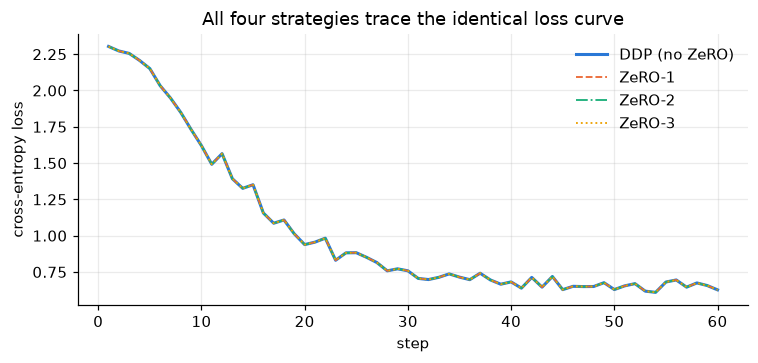

In [5]:
ref = results[0]["final_params"].float()
for s in (1, 2, 3):
    d = (results[s]["final_params"].float() - ref).abs().max().item()
    print(f"{STAGE_NAMES[s]:14s} vs DDP after {STEPS} steps:  max |Δw| = {d}")

fig, ax = plt.subplots(figsize=(7, 3.4))
for s in range(4):
    ax.plot(range(1, STEPS + 1), results[s]["losses"], color=STAGE_COLOR[s], lw=2 if s == 0 else 1.2,
            ls=["-", "--", "-.", ":"][s], label=STAGE_NAMES[s])
ax.set(xlabel="step", ylabel="cross-entropy loss", title="All four strategies trace the identical loss curve")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("figures/loss.png"); plt.show()

## 4. Memory per GPU

Peak memory on a GPU, split by what is in it, and next to it the paper's
formula (Rajbhandari et al. 2020, Figure 1).  The paper counts only *model
states* (params + grads + optimizer); the simulator also sees activations and
ZeRO-3's temporarily gathered layer.

strategy        peak / GPU  model states    paper   formula             vs DDP
DDP (no ZeRO)     36.20 MiB     36.20 MiB    36.20   16Ψ                   1.0x
ZeRO-1             9.90 MiB      9.90 MiB     9.90   4Ψ + 12Ψ/N            3.7x
ZeRO-2             5.97 MiB      5.52 MiB     5.52   2Ψ + 14Ψ/N            6.1x
ZeRO-3             3.46 MiB      1.13 MiB     1.13   16Ψ/N                10.5x


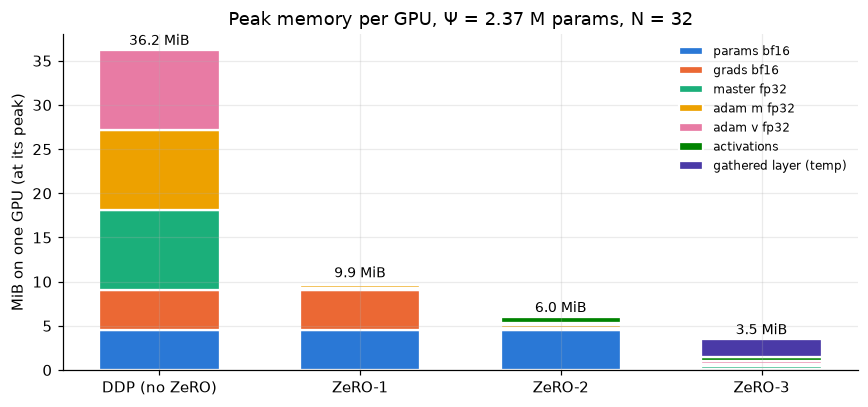

In [6]:
print(f"{'strategy':14s} {'peak / GPU':>11s} {'model states':>13s} {'paper':>8s}   {'formula':18s} {'vs DDP':>7s}")
formulas = {0: "16Ψ", 1: "4Ψ + 12Ψ/N", 2: "2Ψ + 14Ψ/N", 3: "16Ψ/N"}
for s in range(4):
    r = results[s]
    print(f"{STAGE_NAMES[s]:14s} {r['peak_bytes']/MiB:8.2f} MiB {r['peak_model_state_bytes']/MiB:9.2f} MiB "
          f"{r['paper_model_state_bytes']/MiB:8.2f}   {formulas[s]:18s} {results[0]['peak_bytes']/r['peak_bytes']:6.1f}x")

fig, ax = plt.subplots(figsize=(8, 3.8))
for s in range(4):
    bottom = 0
    for cat in CAT_ORDER:
        v = results[s]["peak_breakdown"].get(cat, 0) / MiB
        if v:
            ax.bar(s, v, bottom=bottom, color=CAT_COLOR[cat], width=0.6, edgecolor="white", linewidth=1.5,
                   label=cat if s == 0 or cat in (CAT_ACT, CAT_TMP) and s == 3 else None)
            bottom += v
    ax.text(s, bottom + 0.6, f"{bottom:.1f} MiB", ha="center", fontsize=9)
ax.set(xticks=range(4), xticklabels=[STAGE_NAMES[s] for s in range(4)], ylabel="MiB on one GPU (at its peak)",
       title=f"Peak memory per GPU, Ψ = {psi/1e6:.2f} M params, N = 32")
h, l = ax.get_legend_handles_labels(); ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig("figures/peak_memory.png"); plt.show()

### 4.1 Memory *during* one step

The peak number hides the mechanism.  Here is GPU 0's ledger after every
phase of one step, for each strategy.  Read left to right:

* **DDP / ZeRO-1** — memory *rises* through backward as full gradients pile
  up, then drops after the optimizer frees them.  ZeRO-1 starts 26 MiB lower
  because it owns only 1/32 of the fp32 states.
* **ZeRO-2** — memory *falls* through backward: each layer's gradient is
  reduce-scattered the moment it exists and only 1/32 of it is kept.  The full
  gradient never sits in memory.  Same collectives as ZeRO-1, different
  timing — that is the entire difference between the two stages.
* **ZeRO-3** — a sawtooth.  Each tooth is one layer's weights being gathered
  (2 MiB for a 1024×1024 layer) and freed.  Notice the teeth in backward too:
  the weights are gathered a *second* time, which is where the extra
  communication comes from.

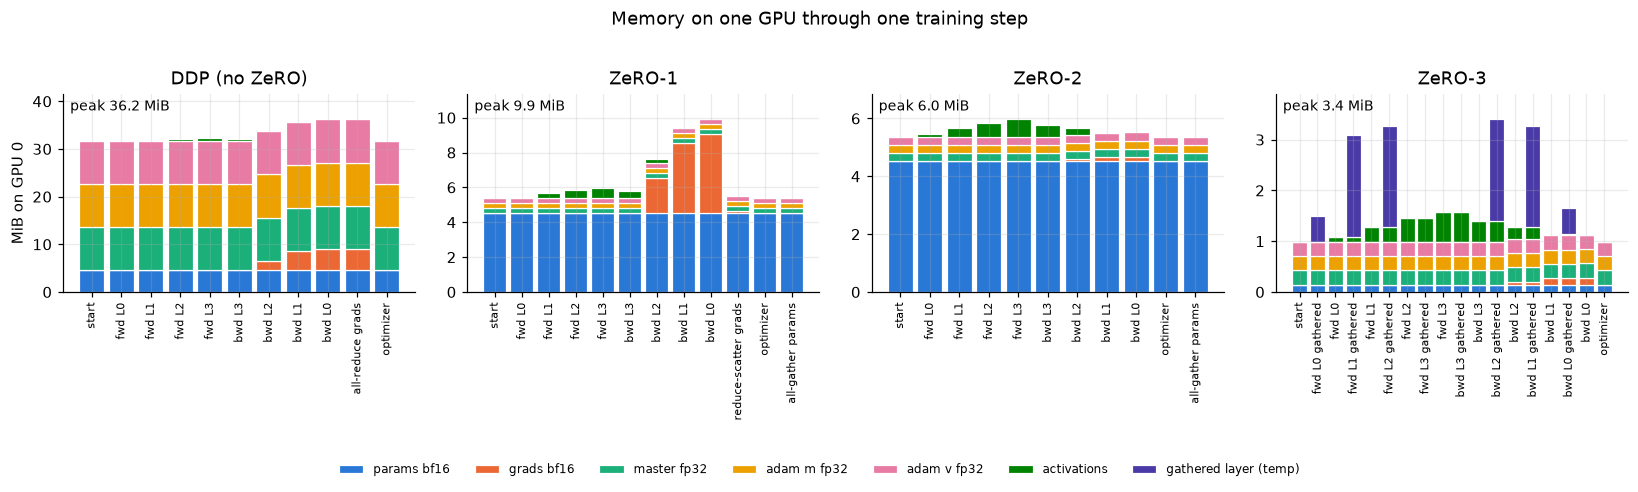

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=False)
for s, ax in zip(range(4), axes):
    tl = results[s]["timeline"]
    labels = [l for l, _ in tl]
    x = range(len(tl))
    bottom = [0.0] * len(tl)
    for cat in CAT_ORDER:
        vals = [b.get(cat, 0) / MiB for _, b in tl]
        if any(vals):
            ax.bar(x, vals, bottom=bottom, color=CAT_COLOR[cat], width=0.85, label=cat, edgecolor="white", linewidth=0.8)
            bottom = [a + b for a, b in zip(bottom, vals)]
    ax.set(title=STAGE_NAMES[s], xticks=list(x))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_ylim(0, max(bottom) * 1.15)
    ax.text(0.02, 0.97, f"peak {max(bottom):.1f} MiB", transform=ax.transAxes, va="top", fontsize=9)
axes[0].set_ylabel("MiB on GPU 0")
h, l = axes[3].get_legend_handles_labels()
fig.legend(h, l, frameon=False, fontsize=8, ncol=7, loc="lower center", bbox_to_anchor=(0.5, -0.12))
fig.suptitle("Memory on one GPU through one training step", y=1.02)
fig.tight_layout(); fig.savefig("figures/timeline.png", bbox_inches="tight"); plt.show()

## 5. Communication per GPU

Bytes each GPU sends and receives per step, measured by the fabric, next to the
paper's claim: DDP, ZeRO-1 and ZeRO-2 all move **2Ψ elements** per step;
ZeRO-3 moves **3Ψ** — 1.5×.

Why: an all-reduce of the gradient (2Ψ) is *exactly* a reduce-scatter (Ψ) plus
an all-gather (Ψ).  ZeRO-1/2 do the reduce-scatter on the gradient and the
all-gather on the *updated parameters* instead — same bytes, but the
parameters come back already updated, so nobody needs the full gradient.
ZeRO-3 cannot keep the gathered parameters between forward and backward
(that would cost 2Ψ of memory again), so it gathers them twice: +Ψ.

strategy         measured    paper  collectives per step
DDP (no ZeRO)     8.77 MiB  8.77 MiB  8 all-reduce
ZeRO-1            8.77 MiB  8.77 MiB  8 reduce-scatter, 8 all-gather
ZeRO-2            8.77 MiB  8.77 MiB  8 reduce-scatter, 8 all-gather
ZeRO-3           13.15 MiB 13.15 MiB  16 all-gather, 8 reduce-scatter


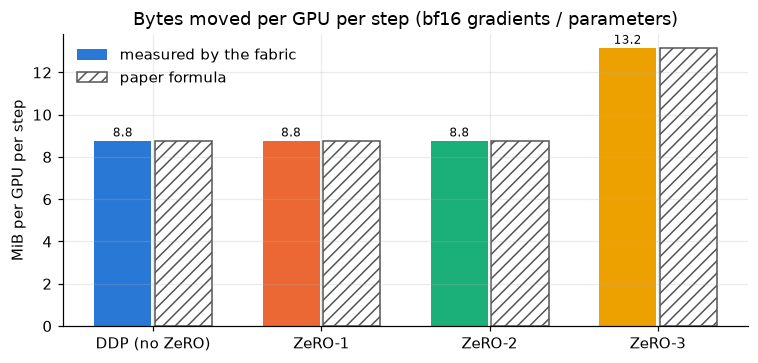

In [8]:
print(f"{'strategy':14s} {'measured':>10s} {'paper':>8s}  collectives per step")
for s in range(4):
    r = results[s]
    calls = ", ".join(f"{int(v)} {k.replace('_', '-')}" for k, v in r["collective_calls_per_step"].items())
    print(f"{STAGE_NAMES[s]:14s} {r['comm_bytes_per_gpu_per_step']/MiB:7.2f} MiB {r['paper_comm_bytes']/MiB:5.2f} MiB  {calls}")

fig, ax = plt.subplots(figsize=(7, 3.4))
meas = [results[s]["comm_bytes_per_gpu_per_step"] / MiB for s in range(4)]
paper = [results[s]["paper_comm_bytes"] / MiB for s in range(4)]
ax.bar([s - 0.18 for s in range(4)], meas, width=0.34, color=[STAGE_COLOR[s] for s in range(4)], label="measured by the fabric")
ax.bar([s + 0.18 for s in range(4)], paper, width=0.34, color="none", edgecolor="#555", hatch="///", label="paper formula")
for s in range(4):
    ax.text(s - 0.18, meas[s] + 0.2, f"{meas[s]:.1f}", ha="center", fontsize=8)
ax.set(xticks=range(4), xticklabels=[STAGE_NAMES[s] for s in range(4)], ylabel="MiB per GPU per step",
       title="Bytes moved per GPU per step (bf16 gradients / parameters)")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("figures/comm.png"); plt.show()

## 6. Computation per GPU

Three separate things, because they behave differently:

1. **Forward + backward FLOPs** — identical in every stage.  Each GPU still
   multiplies its own micro-batch through the *full* model; ZeRO changes
   who *stores* a weight, not who *uses* it.
2. **Optimizer work** — DDP updates all Ψ parameters on every GPU (32× redundant).
   ZeRO-1/2/3 update Ψ/N each.  Measured below with one GPU alone on one
   thread, because per-thread timings inside the 32-thread run are dominated
   by GIL contention and would be misleading.
3. **Waiting on the fabric** — the extra all-gathers of ZeRO-3 are extra
   synchronisation points; real systems hide them by prefetching the next
   layer while computing the current one.

In [9]:
r0 = results[0]
print(f"forward+backward FLOPs per GPU per step (6·Ψ·batch):  {r0['flops_per_gpu_per_step']/1e9:.3f} GFLOP  -- same for every stage")
print(f"optimizer elements updated per GPU per step: DDP {results[0]['optimizer_elements_per_gpu']:,}  |  "
      f"ZeRO-1/2/3 {results[1]['optimizer_elements_per_gpu']:,}  (÷{results[0]['optimizer_elements_per_gpu']//results[1]['optimizer_elements_per_gpu']})")

bench = optimizer_microbench(sum(p.padded for p in spec.params), 32)
print("\nAdam update, one GPU alone, single thread:")
for k, v in bench.items():
    print(f"  {k:14s} {v*1e3:7.3f} ms")
print(f"  -> {list(bench.values())[0]/list(bench.values())[1]:.0f}x less optimizer time per GPU with any ZeRO stage")

print("\ncollective calls per step (synchronisation points):")
for s in range(4):
    print(f"  {STAGE_NAMES[s]:14s} {sum(results[s]['collective_calls_per_step'].values()):.0f}")

print("\nwall-clock of the whole 32-thread simulation per step (ms) — NOT a GPU-time proxy, shown for honesty:")
for s in range(4):
    w = results[s]["wall_per_step"]
    print(f"  {STAGE_NAMES[s]:14s} total {results[s]['wall_total_per_step']*1e3:5.0f}  " +
          "  ".join(f"{k} {v*1e3:4.0f}" for k, v in w.items()))

forward+backward FLOPs per GPU per step (6·Ψ·batch):  0.911 GFLOP  -- same for every stage
optimizer elements updated per GPU per step: DDP 2,372,640  |  ZeRO-1/2/3 74,145  (÷32)



Adam update, one GPU alone, single thread:
  full (DDP)       9.088 ms
  shard (1/32)     0.144 ms
  -> 63x less optimizer time per GPU with any ZeRO stage

collective calls per step (synchronisation points):
  DDP (no ZeRO)  8
  ZeRO-1         16
  ZeRO-2         16
  ZeRO-3         24

wall-clock of the whole 32-thread simulation per step (ms) — NOT a GPU-time proxy, shown for honesty:
  DDP (no ZeRO)  total   512  forward   74  backward  114  collectives  180  optimizer  127
  ZeRO-1         total   435  forward   63  backward   99  collectives  175  optimizer   80
  ZeRO-2         total   423  forward   59  collectives  153  backward  233  optimizer   79
  ZeRO-3         total   463  collectives  155  forward   91  backward  264  optimizer   92


## 7. How the saving scales with the number of GPUs

Same model, same stage, N = 1, 2, 4, 8, 16, 32.  DDP is flat (every GPU
holds everything, no matter how many there are).  ZeRO-3 falls as 1/N …
until it hits the floor set by the largest single layer that must be
gathered in full (the dashed line).  Activations are also flat: ZeRO does
nothing for them — that is what activation checkpointing is for.

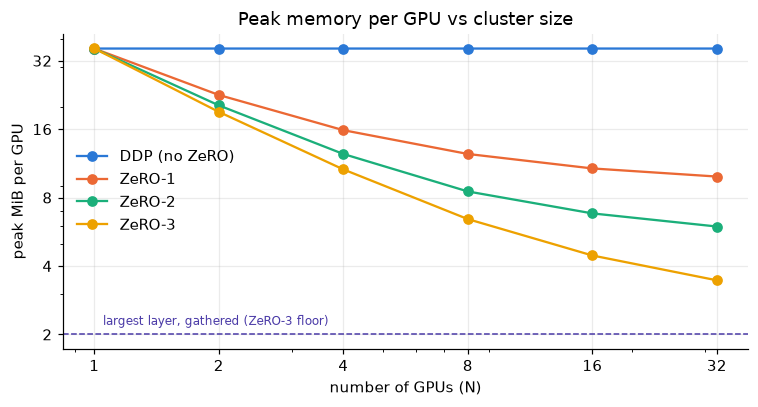

DDP (no ZeRO)  N=1:  36.20  N=2:  36.20  N=4:  36.20  N=8:  36.20  N=16:  36.20  N=32:  36.20
ZeRO-1         N=1:  36.20  N=2:  22.63  N=4:  15.84  N=8:  12.44  N=16:  10.75  N=32:   9.90
ZeRO-2         N=1:  36.20  N=2:  20.36  N=4:  12.44  N=8:   8.51  N=16:   6.82  N=32:   5.97
ZeRO-3         N=1:  36.23  N=2:  19.07  N=4:  10.65  N=8:   6.43  N=16:   4.45  N=32:   3.46


In [10]:
Ns = [1, 2, 4, 8, 16, 32]
scan = {s: [run_stage(s, n_gpus=n, steps=3, verbose=False)["peak_bytes"] / MiB for n in Ns] for s in range(4)}

fig, ax = plt.subplots(figsize=(7, 3.8))
for s in range(4):
    ax.plot(Ns, scan[s], marker="o", ms=6, color=STAGE_COLOR[s], label=STAGE_NAMES[s])
ax.axhline(2 * spec.largest_layer_params / MiB, ls="--", color="#4a3aa7", lw=1)
ax.text(1.05, 2 * spec.largest_layer_params / MiB * 1.1, "largest layer, gathered (ZeRO-3 floor)", fontsize=8, color="#4a3aa7")
ax.set(xscale="log", yscale="log", xticks=Ns, xticklabels=Ns, xlabel="number of GPUs (N)", ylabel="peak MiB per GPU",
       title="Peak memory per GPU vs cluster size")
ax.set_yticks([2, 4, 8, 16, 32]); ax.set_yticklabels(["2", "4", "8", "16", "32"]); ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("figures/scan_n.png"); plt.show()
for s in range(4):
    print(f"{STAGE_NAMES[s]:14s} " + "  ".join(f"N={n}: {v:6.2f}" for n, v in zip(Ns, scan[s])))

## 8. What this means for a real model

The simulator confirmed the paper's formulas to two decimals, so I can trust
them at sizes I cannot simulate.  Model states only (no activations), 32 GPUs
with 80 GB each:

In [11]:
GB = 1e9
print(f"{'model':>8s} | " + " | ".join(f"{STAGE_NAMES[s]:>14s}" for s in range(4)) + "   (per-GPU model states, 32 x 80 GB GPUs)")
for name, P in (("1 B", 1e9), ("7 B", 7e9), ("13 B", 13e9), ("70 B", 70e9), ("175 B", 175e9)):
    row = []
    for s in range(4):
        b = paper_model_state_bytes(P, 32, s) / GB
        row.append(f"{b:8.1f} GB {'ok' if b < 80 else 'NO':>3s}")
    print(f"{name:>8s} | " + " | ".join(row))

   model |  DDP (no ZeRO) |         ZeRO-1 |         ZeRO-2 |         ZeRO-3   (per-GPU model states, 32 x 80 GB GPUs)
     1 B |     16.0 GB  ok |      4.4 GB  ok |      2.4 GB  ok |      0.5 GB  ok
     7 B |    112.0 GB  NO |     30.6 GB  ok |     17.1 GB  ok |      3.5 GB  ok
    13 B |    208.0 GB  NO |     56.9 GB  ok |     31.7 GB  ok |      6.5 GB  ok
    70 B |   1120.0 GB  NO |    306.2 GB  NO |    170.6 GB  NO |     35.0 GB  ok
   175 B |   2800.0 GB  NO |    765.6 GB  NO |    426.6 GB  NO |     87.5 GB  NO


## 9. What I take away

1. **Data parallelism wastes memory by replication.** 32 GPUs, 32 identical
   copies of 16 bytes/parameter.  Only the *activations* actually differ
   between GPUs (different micro-batches).
2. **ZeRO-1 removes the biggest redundancy at zero cost.** The 12 bytes/param
   of fp32 master + Adam moments were only ever *read* by the optimizer, and
   the optimizer update is element-wise — so each GPU can own 1/N of them and
   update just those.  The reduce-scatter + all-gather it needs is exactly
   what an all-reduce already was.  3.7× less memory here, and the optimizer
   step gets ~N× cheaper per GPU as a bonus.
3. **ZeRO-2 is ZeRO-1 with better timing.** Reduce-scatter each layer's
   gradient *during* backward instead of after, and the full gradient never
   exists.  Same bytes on the wire (2Ψ), another 2 bytes/param saved.
4. **ZeRO-3 is the first stage that costs something.** Sharding the parameters
   themselves means every layer is all-gathered just-in-time — twice per step,
   because keeping it between forward and backward would undo the saving.
   Memory falls to 16Ψ/N + one gathered layer; communication rises 1.5×.
   This is why ZeRO-3 wants fast interconnects and prefetching.
5. **Compute is untouched.** Same FLOPs, same loss curve, same weights to the
   bit.  ZeRO is purely a question of *where* the 16 bytes live.
6. **Two things ZeRO does not shrink:** activations (the per-GPU work is the
   same), and the largest single layer (must exist in full on one GPU while it
   is used).  Those need activation checkpointing and tensor parallelism
   respectively — which is what the next sessions are for.